In [113]:
import pandas as pd
import numpy as np

df = pd.read_csv("titanic_data_updated.csv")
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
443,444,yes,second,"Reynaldo, Ms. Encarnacion",female,28.0,0,0,230434,13.0000,NaN,S
48,49,no,third,"Samaan, Mr. Youssef",male,NaN,2,0,2662,21.6792,NaN,C
813,814,no,third,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S


In [114]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [115]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [116]:
df.sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
466,no,second,male,NaN,0,0,0.0000,NaN,S
856,yes,first,female,45.0,1,1,164.8667,NaN,S
403,no,third,male,28.0,1,0,15.8500,NaN,S


In [117]:
# x = feature columns
x = df.drop(['Survived'],axis=1)
# x.sample(3)

# y = traget column
y =  df['Survived']
y.sample(3)

44     yes
408     no
643    yes
Name: Survived, dtype: object

Train-Test split - using scikit-learn

In [118]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [119]:
x_train.shape

(712, 8)

In [120]:
y_train.shape

(712,)

In [121]:
x_test.shape

(179, 8)

In [122]:
y_test.shape

(179,)

### Numerical Missing Values Imputation Using Pandas

Imputing with Mean value of 'Age'

In [123]:
mean_age = df['Age'].mean()
x_train['Age_Mean_Imputor'] = x_train['Age'].fillna(mean_age)

In [124]:
x_train.isnull().sum()

Pclass                0
Sex                   0
Age                 140
SibSp                 0
Parch                 0
Fare                  0
Cabin               553
Embarked              2
Age_Mean_Imputor      0
dtype: int64

Imputing with Median value of 'Age'

In [125]:
age_median = x_train['Age'].median()
x_train['Age_Median_Imputor'] = x_train['Age'].fillna(age_median)
x_train.isnull().sum()

Pclass                  0
Sex                     0
Age                   140
SibSp                   0
Parch                   0
Fare                    0
Cabin                 553
Embarked                2
Age_Mean_Imputor        0
Age_Median_Imputor      0
dtype: int64

<Axes: xlabel='Age_Mean_Imputor', ylabel='Density'>

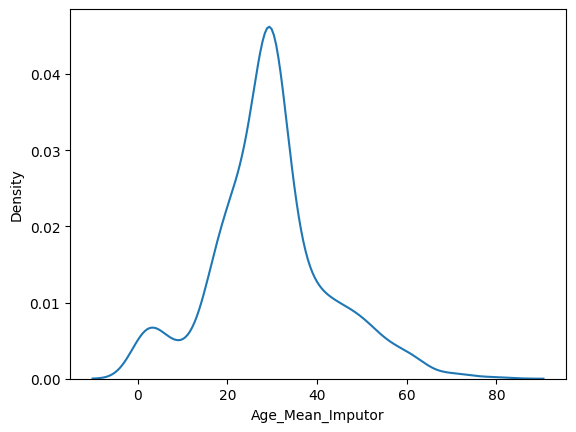

In [126]:
import seaborn as sns

sns.kdeplot(data=x_train, x='Age_Mean_Imputor')

<Axes: xlabel='Age_Median_Imputor', ylabel='Density'>

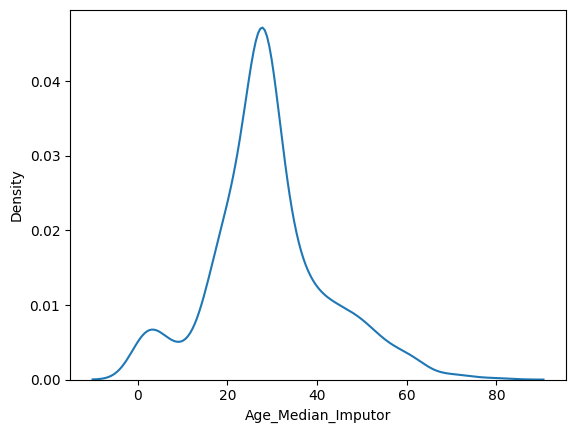

In [127]:
sns.kdeplot(data=x_train, x='Age_Median_Imputor')

### Imputing using Scikit-learn Simple Imputer

In [128]:
from sklearn.impute import SimpleImputer
import numpy as np

age_imputer = SimpleImputer(missing_values=np.nan,strategy='mean')
age_imputer.fit(x_train[['Age']]) # fit() only in training data

x_train['Age'] = age_imputer.transform(x_train[['Age']])

In [129]:
x_train.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                 553
Embarked                2
Age_Mean_Imputor        0
Age_Median_Imputor      0
dtype: int64

In [130]:
x_train.drop(['Age_Mean_Imputor','Age_Median_Imputor'],axis=1,inplace=True)

In [131]:
x_train.sample(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
640,third,male,20.000000,0,0,7.8542,NaN,S
697,third,female,29.498846,0,0,7.7333,NaN,Q


Same for the test data,, but , no fit() here, Test data should not fit().<br>
for train data: 
- fit()<br>
- transform()<br>
<br>
for test data: 
- fit()


In [132]:
# reuse the imputer_object here
x_test['Age'] = age_imputer.transform(x_test[['Age']])

In [133]:
x_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [134]:
x_test.sample(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
292,second,male,36.0,0,0,12.875,D,C
767,third,female,30.5,0,0,7.750,NaN,Q


### Categorical Missing Value Imputation 

Impute 'Embarked' column with 'mode' - most frequent value

In [135]:
embark_imputer = SimpleImputer(missing_values=np.nan,strategy='most_frequent')
embark_imputer.fit(x_train[['Embarked']])

x_train['Embarked'] = embark_imputer.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embark_imputer.transform(x_test[['Embarked']]).ravel()

# ravel() --> to convert returned result (2D) into 1D

Now check null value count

In [136]:
x_train.isnull().sum() # 

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

In [137]:
x_test.isnull().sum() # no null values in 'Age' and 'Embarked' columns

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

Impute using 'Missing' string - for 'Cabin' column

In [138]:
cabin_imputer = SimpleImputer(missing_values=np.nan,strategy='constant',fill_value='Missing', add_indicator=True)
cabin_imputer.fit(x_train[['Cabin']])

x_train[['Cabin','Cabin_Missing_Indicator']] = cabin_imputer.transform(x_train[['Cabin']])
x_test[['Cabin','Cabin_Missing_Indicator']] = cabin_imputer.transform(x_test[['Cabin']])

# no ravel() here because, transform() returns a 2D and we need that 2D data, (2 columns, Cabin and Cabin_Missing_Indicator)

In [139]:
x_train.isnull().sum() # cleaned - no null values anywhere

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
Cabin_Missing_Indicator    0
dtype: int64

In [140]:
x_test.isnull().sum() # cleaned - no null values anywhere

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
Cabin_Missing_Indicator    0
dtype: int64

In [141]:
x_train.sample(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Missing_Indicator
236,second,male,44.000000,1,0,26.0000,Missing,S,True
661,third,male,40.000000,0,0,7.2250,Missing,C,True
542,third,female,11.000000,4,2,31.2750,Missing,S,True
816,third,female,23.000000,0,0,7.9250,Missing,S,True
405,second,male,34.000000,1,0,21.0000,Missing,S,True
501,third,female,21.000000,0,0,7.7500,Missing,Q,True
650,third,male,29.498846,0,0,7.8958,Missing,S,True
637,second,male,31.000000,1,1,26.2500,Missing,S,True
869,third,male,4.000000,1,1,11.1333,Missing,S,True
490,third,male,29.498846,1,0,19.9667,Missing,S,True


### Outliers Detection Using Z-Score

z-score = (x - mean)/std --> x = each value<br>
outliers = z_score > 3

'Age' outliers

In [142]:
mean_age = x_train['Age'].mean()
std_age = x_train['Age'].std()

x_train['z_score_age'] = (x_train['Age']-mean_age)/std_age

outliers_age = x_train[abs(x_train['z_score_age'])>3]

print(f"Number of outliers: {len(outliers_age)}")
# display(outliers_age)
# x_train.sort_values(by='Age').tail(10)

Number of outliers: 5


'Fare' outliers

In [143]:
mean_fare = x_train['Fare'].mean()
std_fare = x_train['Fare'].std()

x_train['z_score_fare'] = (x_train['Fare']-mean_fare)/std_fare
outliers_fare = x_train[abs(x_train['z_score_fare'])>3]

print(f"Number of outlier fare: {len(outliers_fare)}")
display(outliers_fare.head())

Number of outlier fare: 17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Missing_Indicator,z_score_age,z_score_fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
742,first,female,21.0,2,2,262.3750,B57 B59 B63 B66,C,False,-0.654044,4.421605
380,first,female,42.0,0,0,227.5250,Missing,C,True,0.962049,3.751020


### Outliers Detection Using IQR
IQR = Q3 - Q1<br>
outliers_max_range = Q3 + 1.5 * IQR<br>
outliers_min_range = Q1 - 1.5* IQR

'Age' outliers using IQR<br>

In [144]:
age_q1 = x_train['Age'].quantile(0.25)
age_q3 = x_train['Age'].quantile(0.75)

age_iqr = age_q3 - age_q1

max_range = age_q3 + (1.5 * age_iqr)
min_range = age_q1 - (1.5 * age_iqr)

print(f"Max: {max_range}\nMin: {min_range}")

age_outliers = x_train[(x_train['Age']<min_range) | (x_train['Age'] > max_range)]
print("Number of age outliers: ",len(age_outliers))
display(age_outliers.sample(5))

Max: 54.5
Min: 2.5
Number of age outliers:  54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Missing_Indicator,z_score_age,z_score_fare
326,third,male,61.0,0,0,6.2375,Missing,S,True,2.424228,-0.507004
366,first,female,60.0,1,0,75.2500,D37,C,False,2.347271,0.820937
467,first,male,56.0,0,0,26.5500,Missing,S,True,2.039444,-0.116150
829,first,female,62.0,0,0,80.0000,B28,S,False,2.501185,0.912337
587,first,male,60.0,1,1,79.2000,B41,C,False,2.347271,0.896943


'Fare' outliers using IQR

In [145]:
fare_q1 = x_train['Fare'].quantile(0.25)
fare_q3 = x_train['Fare'].quantile(0.75)

fare_iqr = fare_q3 - fare_q1

max_range = fare_q3 + (1.5 * fare_iqr)
min_range = max(0,fare_q1 - (1.5 * fare_iqr)) # becasue the value goes to negative side, so capping at 0

print(f"Max: {max_range}\nMin: {min_range}")

fare_outliers = x_train[(x_train['Fare']<min_range) | (x_train['Fare'] > max_range)]
print("Number of fare outliers: ",len(fare_outliers))
display(fare_outliers.sample(5))

Max: 64.3625
Min: 0
Number of fare outliers:  96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Missing_Indicator,z_score_age,z_score_fare
27,first,male,19.000000,3,2,263.0000,C23 C25 C27,S,False,-8.079576e-01,4.433631
159,third,male,29.498846,8,2,69.5500,Missing,S,True,2.734055e-16,0.711258
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
269,first,female,35.000000,0,0,135.6333,C99,S,False,4.233512e-01,1.982835
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539


For this dataset, based on the kde plot of 'Age' and 'Fare' and their distribution, using z_score is better for 'Age' outliers detection and IQR is better for 'Fare' outliers detection

In [146]:
# omitting outliers age from the x_train data
x_train = x_train[abs(x_train['z_score_age']) <=3]
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Missing_Indicator,z_score_age,z_score_fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [151]:
# Capping 'Fare' at 0 to max range of IQR outliers
x_train['Fare'] = x_train['Fare'].clip(min_range,max_range)
print(x_train['Fare'].min())
print(x_train['Fare'].max())

0.0
64.3625


In [154]:
# x_train.sort_values(by='Age').tail(5)
x_train.sort_values(by='Fare').tail(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Missing_Indicator,z_score_age,z_score_fare
856,first,female,45.000000,1,1,64.3625,Missing,S,True,1.192919e+00,2.545346
737,first,male,35.000000,0,0,64.3625,B101,C,False,4.233512e-01,9.231235
180,third,female,29.498846,8,2,64.3625,Missing,S,True,2.734055e-16,0.711258
792,third,female,29.498846,8,2,64.3625,Missing,S,True,2.734055e-16,0.711258
700,first,female,18.000000,1,0,64.3625,C62 C64,C,False,-8.849144e-01,3.751020
